Dataset Loaded Successfully!
Total Employees: 2500

Median Salary: 34.42

Training Features: (2000, 20)
Testing Features: (500, 20)
Training Target: (2000,)
Testing Target: (500,)

Decision Tree Model Trained Successfully!

DECISION TREE MODEL
Median Salary: 34.42
Accuracy: 96.40%

Actual vs Predicted Salary Class
--------------------------------
    Actual Salary Class  Predicted Salary Class
0                     0                       0
1                     1                       1
2                     1                       1
3                     1                       1
4                     1                       1
5                     0                       0
6                     0                       0
7                     0                       0
8                     0                       1
9                     0                       0
10                    1                       1
11                    0                       0
12                    0    

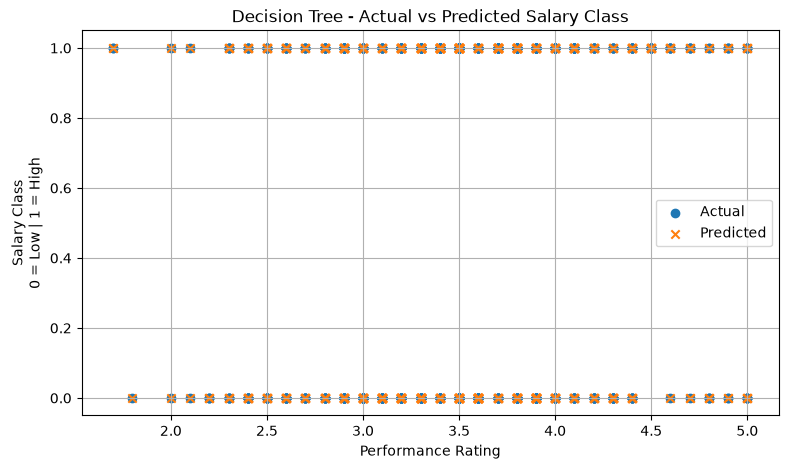

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("preprocessed_data_1.csv")

print("Dataset Loaded Successfully!")
print("Total Employees:", len(df))

median_salary = df["Salary_LPA"].median()

df["Salary_Class"] = (
    df["Salary_LPA"] >= median_salary
).astype(int)

print("\nMedian Salary:", round(median_salary, 2))

X = df[
    [
        "Age",
        "Experience_Years",
        "Education",
        "Department",
        "Job_Level",
        "Performance_Rating",
        "Projects_Completed",
        "Certifications",
        "Weekly_Work_Hours",
        "Remote_Work",
        "City_Tier",
        "Job_Satisfaction"
    ]
]

y = df["Salary_Class"]
X = pd.get_dummies(
    X,
    drop_first=True
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=42
)
model.fit(X_train, y_train)

print("\nDecision Tree Model Trained Successfully!")
y_pred = model.predict(X_test)
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n==============================")
print("DECISION TREE MODEL")
print("==============================")

print("Median Salary:", round(median_salary, 2))

print(
    "Accuracy:",
    f"{accuracy * 100:.2f}%"
)

result = pd.DataFrame({
    "Actual Salary Class": y_test.values,
    "Predicted Salary Class": y_pred
})

print("\nActual vs Predicted Salary Class")
print("--------------------------------")

print(result.head(20))

print("\nClassification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Low", "High"]
    )
)
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix")
print("----------------")

print(cm)
plt.figure(figsize=(9, 5))

plt.scatter(
    X_test["Performance_Rating"],
    y_test,
    label="Actual"
)

plt.scatter(
    X_test["Performance_Rating"],
    y_pred,
    marker="x",
    label="Predicted"
)

plt.title(
    "Decision Tree - Actual vs Predicted Salary Class"
)

plt.xlabel("Performance Rating")

plt.ylabel(
    "Salary Class\n0 = Low | 1 = High"
)

plt.legend()

plt.grid(True)

plt.show()



